In [ ]:
!pwd
import sys
sys.path.append('.')

/users/khordadi/truejit/evaluation/compilation-plan


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif"],
})

PROFILE_ROOT = Path('/users/khordadi/truejit/profiles')
SENTINEL = 999999999999  # used for missing spec data

## Load all profiles

In [3]:
def load_all_profiles(profile_root: Path = PROFILE_ROOT) -> pd.DataFrame:
    """Load every profile.csv under profile_root and tag each row with benchmark/workload."""
    frames = []
    for f in sorted(profile_root.rglob('profile.csv')):
        df = pd.read_csv(f)
        # path layout: profiles/<benchmark>/<workload>/profile.csv
        df['benchmark'] = f.parts[-3]
        df['workload']  = f.parts[-2]
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

all_df = load_all_profiles()
print(f"Loaded {len(all_df):,} function rows from {all_df.groupby(['benchmark','workload']).ngroups} profiles")
all_df.head(3)

Loaded 49,059 function rows from 92 profiles


,id,name,size.bytecode,size.static,start.jit,exec.jit,freq.jit,compilation.jit,size.dynamic.jit,start.interp,exec.interp,freq.interp,exec.spec,compilation.spec,size.dynamic.spec,benchmark,workload
0,9,_start,84,984,68510.0,0.0,0.0,4613041.0,984.0,63070.0,0.0,0.0,999999999999,999999999999,999999999999,coremark,default
1,8,__wasm_call_ctors,3,512,4682731.0,0.0,1.0,1476353.0,512.0,66840.0,0.0,1.0,999999999999,999999999999,999999999999,coremark,default
2,42,__main_void,214,1392,6159714.0,0.0,1.0,4932321.0,1392.0,67460.0,0.0,1.0,999999999999,999999999999,999999999999,coremark,default


## Exploratory analysis

Key question: how does `exec.interp` relate to `exec.jit`?

In [4]:
# Focus on functions actually executed in both modes
active = all_df[(all_df['exec.jit'] > 0) & (all_df['exec.interp'] > 0)].copy()
active['ratio'] = active['exec.interp'] / active['exec.jit']

print(f"Functions executed in both JIT and interp: {len(active):,}")
print()
print("exec.interp / exec.jit ratio:")
print(active['ratio'].describe().to_string())
print(f"Median: {active['ratio'].median():.1f}x")

Functions executed in both JIT and interp: 3,245

exec.interp / exec.jit ratio:
count     3245.000000
mean       193.236614
std        446.645234
min          0.500000
25%         26.333333
50%         81.185185
75%        224.400000
max      12718.000000
Median: 81.2x


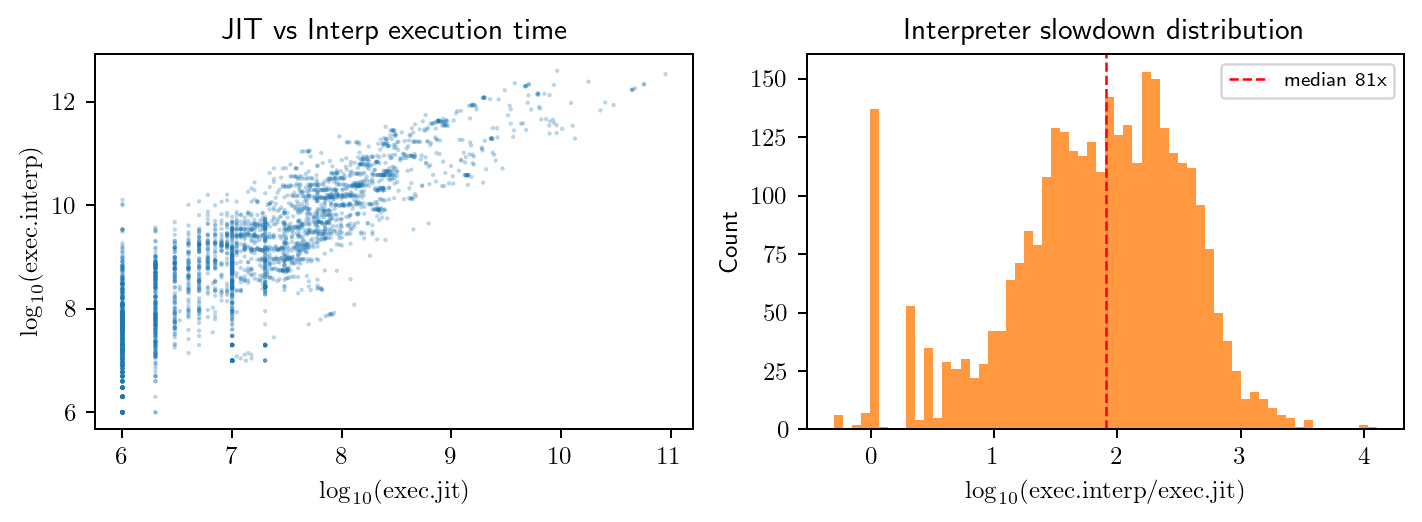

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=180)

# Scatter: log exec.jit vs log exec.interp
ax = axes[0]
ax.scatter(np.log10(active['exec.jit'] + 1), np.log10(active['exec.interp'] + 1),
           s=3, alpha=0.3, color='tab:blue', edgecolors='none')
ax.set_xlabel(r'$\log_{10}(\mathrm{exec.jit})$')
ax.set_ylabel(r'$\log_{10}(\mathrm{exec.interp})$')
ax.set_title('JIT vs Interp execution time')

# Histogram of slowdown ratio (log scale)
ax = axes[1]
ax.hist(np.log10(active['ratio']), bins=60, color='tab:orange', edgecolor='none', alpha=0.8)
ax.axvline(np.log10(active['ratio'].median()), color='red', lw=1, linestyle='--',
           label=f"median {active['ratio'].median():.0f}x")
ax.set_xlabel(r'$\log_{10}(\mathrm{exec.interp} / \mathrm{exec.jit})$')
ax.set_ylabel('Count')
ax.set_title('Interpreter slowdown distribution')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [6]:
# Per-benchmark median slowdown
per_bench = active.groupby('benchmark')['ratio'].median().sort_values(ascending=False)
print("Median interp/jit slowdown per benchmark:")
print(per_bench.to_string())

Median interp/jit slowdown per benchmark:
benchmark
snappy            249.436508
sp                241.260514
mnist             237.294118
cg                225.156250
gcc_loops         217.237679
lu                210.322009
float_mm          208.615385
facedetection     198.166667
bt                191.620968
mg                183.568182
is                174.500000
lbm               165.841463
quicksort         153.000000
espeak            148.500000
ft                144.111111
rawcaudio         136.416667
bzip2             121.500000
cholesky          117.503289
ludcmp            115.355263
rawdaudio          99.916667
nab                97.000000
ffmpeg             92.000000
gnuchess           87.833333
basicmath          82.000000
rijndael           73.500000
namd               69.350000
x264               68.000000
ep                 54.066256
tsf                53.800000
deepsjeng          53.027251
sqlite             48.000000
coremark           47.029834
bitcount           4

## Feature engineering

Features derived purely from the JIT profile (available at estimation time):
- `exec.jit`, `freq.jit` — total execution time and call count
- `compilation.jit` — JIT compilation cost (proxy for code complexity)
- `size.bytecode`, `size.static` — function size in wasm bytes / native bytes
- `size.dynamic.jit` — JIT-generated code size
- Derived: `exec_per_call.jit`, `compilation_per_call.jit`, `code_expansion`, `static_expansion`

We predict in **log space** (log1p) to handle the several orders-of-magnitude range.

In [7]:
FEATURE_COLS_RAW = [
    'exec.jit', 'freq.jit', 'compilation.jit',
    'size.bytecode', 'size.static', 'size.dynamic.jit',
]

def add_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    safe_freq = df['freq.jit'].replace(0, np.nan)
    safe_bc   = df['size.bytecode'].replace(0, np.nan)
    df['exec_per_call.jit']        = df['exec.jit']        / safe_freq
    df['compilation_per_call.jit'] = df['compilation.jit'] / safe_freq
    # code expansion: JIT native bytes per wasm bytecode byte
    df['code_expansion']  = df['size.dynamic.jit'] / safe_bc
    df['static_expansion'] = df['size.static']     / safe_bc
    return df.fillna(0)

FEATURE_COLS = FEATURE_COLS_RAW + [
    'exec_per_call.jit', 'compilation_per_call.jit', 'code_expansion', 'static_expansion'
]

def to_log_features(df: pd.DataFrame) -> np.ndarray:
    """Transform features to log space (log1p to handle zeros)."""
    return np.log1p(df[FEATURE_COLS].values.astype(float))

# Build training set: only rows where both jit and interp were actually executed
train_raw = all_df[
    (all_df['exec.jit'] > 0) &
    (all_df['exec.interp'] > 0) &
    (all_df['freq.jit'] > 0)
].copy()
train_raw = add_derived_features(train_raw)

X_all = to_log_features(train_raw)
y_all = np.log1p(train_raw['exec.interp'].values.astype(float))

print(f"Training samples: {len(X_all):,}")
print(f"Feature matrix shape: {X_all.shape}")

Training samples: 3,245
Feature matrix shape: (3245, 10)


## Model training

Two models:
1. **Ridge regression** in log-space — simple interpretable baseline
2. **Gradient Boosting** in log-space — captures non-linear relationships

Cross-validation: **leave-one-benchmark-out** — tests generalisation to unseen binaries.

In [8]:
benchmarks = train_raw['benchmark'].unique()
print(f"Benchmarks in training data: {sorted(benchmarks)}")

def make_ridge():
    return Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])

def make_gbr():
    return GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05, subsample=0.8,
        min_samples_leaf=5, random_state=42
    )

cv_results = []

for held_out in benchmarks:
    mask_train = train_raw['benchmark'] != held_out
    mask_test  = train_raw['benchmark'] == held_out

    if mask_test.sum() < 5:
        continue

    X_tr, y_tr = X_all[mask_train], y_all[mask_train]
    X_te, y_te = X_all[mask_test],  y_all[mask_test]

    for name, model in [('Ridge', make_ridge()), ('GBR', make_gbr())]:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        r2   = r2_score(y_te, y_pred)
        mape = mean_absolute_percentage_error(
            np.expm1(y_te), np.expm1(y_pred).clip(0)
        )
        cv_results.append({'benchmark': held_out, 'model': name, 'r2': r2, 'mape': mape})

cv_df = pd.DataFrame(cv_results)
print("\nLeave-one-benchmark-out cross-validation (log-space predictions):")
print(cv_df.groupby('model')[['r2', 'mape']].mean().to_string())

Benchmarks in training data: ['2mm', '3mm', 'adi', 'atax', 'basicmath', 'bicg', 'bitcount', 'blowfish', 'bt', 'bzip2', 'cg', 'cholesky', 'cjpeg', 'coremark', 'correlation', 'covariance', 'crc32', 'deepsjeng', 'deriche', 'djpeg', 'doitgen', 'durbin', 'ep', 'espeak', 'facedetection', 'fdtd-2d', 'ffmpeg', 'float_mm', 'floyd-warshall', 'ft', 'gcc_loops', 'gemm', 'gemver', 'gesummv', 'gnuchess', 'gramschmidt', 'hashset', 'heat-3d', 'is', 'jacobi-1d', 'jacobi-2d', 'lbm', 'lu', 'ludcmp', 'mcf', 'mg', 'mnist', 'mvt', 'nab', 'namd', 'nussinov', 'quicksort', 'rawcaudio', 'rawdaudio', 'rijndael', 'seidel-2d', 'sha', 'snappy', 'sp', 'sqlite', 'symm', 'syr2k', 'syrk', 'trisolv', 'trmm', 'tsf', 'whitedb', 'x264']

Leave-one-benchmark-out cross-validation (log-space predictions):
             r2     mape
model                   
GBR    0.604220  3.28451
Ridge  0.569014  1.73305


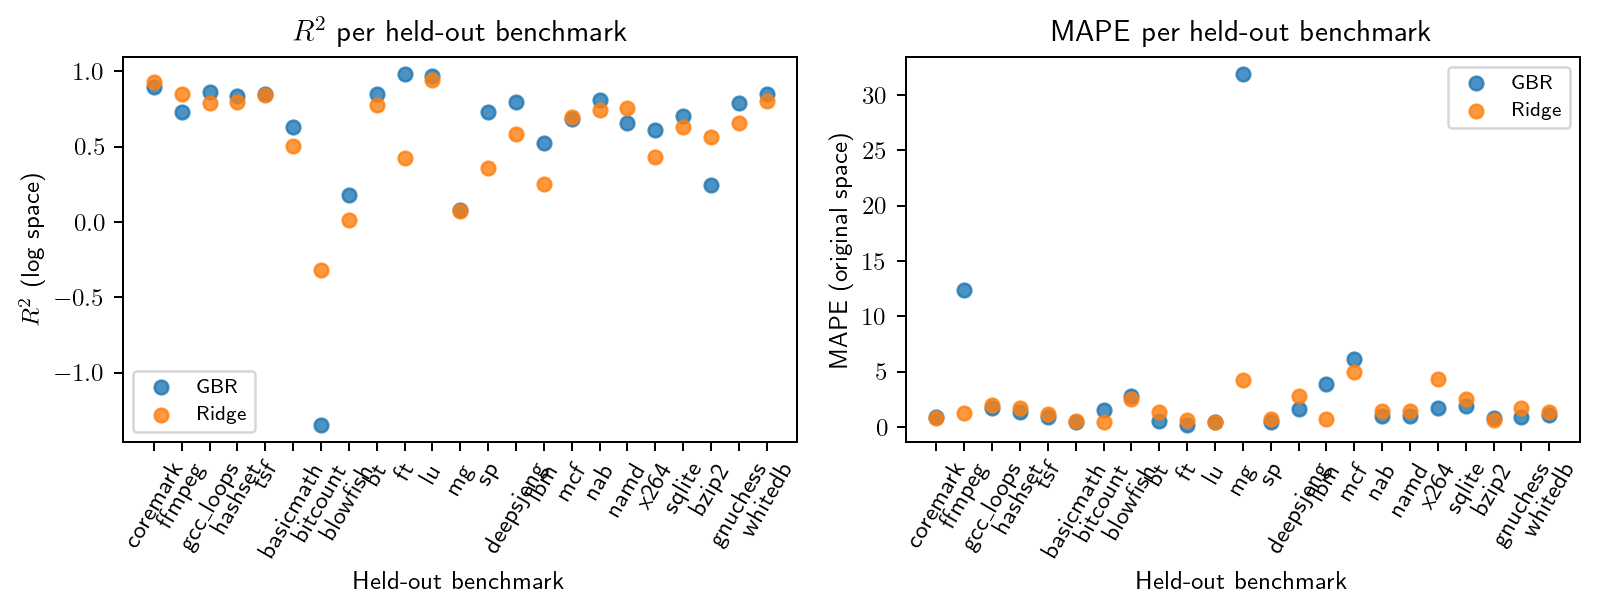

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), dpi=180)

for ax, metric, label in [
    (axes[0], 'r2',   r'$R^2$ (log space)'),
    (axes[1], 'mape', 'MAPE (original space)'),
]:
    for model_name, group in cv_df.groupby('model'):
        ax.scatter(group['benchmark'], group[metric], label=model_name, s=30, alpha=0.8)
    ax.set_ylabel(label)
    ax.set_xlabel('Held-out benchmark')
    ax.tick_params(axis='x', rotation=60)
    ax.legend(fontsize=8)

axes[0].set_title(r'$R^2$ per held-out benchmark')
axes[1].set_title('MAPE per held-out benchmark')
plt.tight_layout()
plt.show()

## Train final model on all data

In [10]:
final_model = make_gbr()
final_model.fit(X_all, y_all)
print("Final GBR model trained on all", len(X_all), "samples")

y_pred_all = final_model.predict(X_all)
print(f"In-sample R\u00b2: {r2_score(y_all, y_pred_all):.4f}")
print(f"In-sample MAPE: {mean_absolute_percentage_error(np.expm1(y_all), np.expm1(y_pred_all).clip(0)):.4f}")

Final GBR model trained on all 3245 samples
In-sample R²: 0.9795
In-sample MAPE: 0.3572


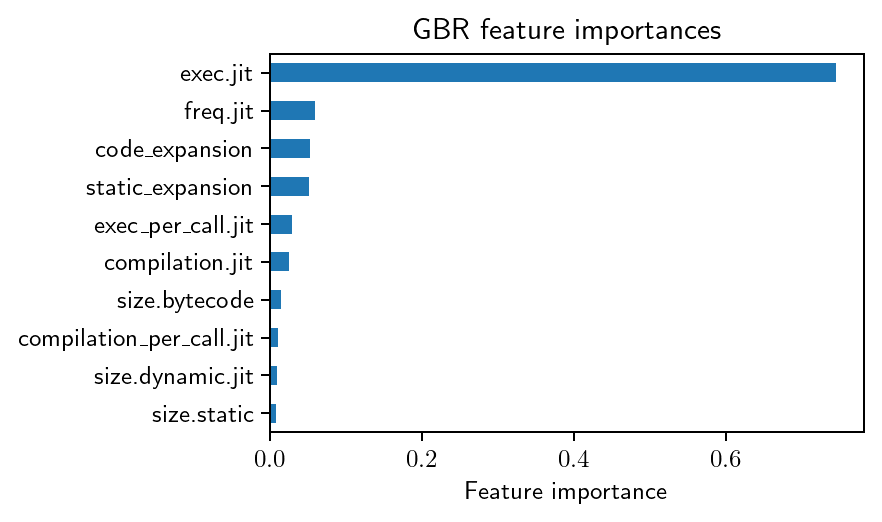

In [11]:
importances = final_model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(5, 3), dpi=180)
feat_imp.plot.barh(ax=ax)
ax.set_xlabel('Feature importance')
ax.set_title('GBR feature importances')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Estimator API

Three public functions:

- **`estimate_interp_from_jit(jit_df, model)`** — fills in the three interp columns from JIT features.
- **`merge_estimated_profile(jit_df, model)`** — returns a complete `profile.csv`-shaped DataFrame ready for the planner.
- **`estimate_from_csv(path, output_csv, model)`** — convenience wrapper around the above two.

In [12]:
def estimate_interp_from_jit(
    jit_df: pd.DataFrame,
    model=None,
) -> pd.DataFrame:
    """
    Predict interpreter execution times for each function in *jit_df*.

    Parameters
    ----------
    jit_df : DataFrame with at minimum the JIT profile columns:
             id, name, size.bytecode, size.static,
             start.jit, exec.jit, freq.jit, compilation.jit, size.dynamic.jit
    model  : fitted sklearn estimator (defaults to the module-level *final_model*).

    Returns
    -------
    DataFrame with three new / updated columns: exec.interp, freq.interp, start.interp
    """
    if model is None:
        model = final_model

    df = add_derived_features(jit_df.fillna(0))

    # freq.interp equals freq.jit (same call counts, different execution mode)
    df['freq.interp']  = df['freq.jit']
    # start.interp: carry over start.jit (planner cares about exec times, not starts)
    df['start.interp'] = df['start.jit']
    # default: zero (function not executed → interp cost is also zero)
    df['exec.interp']  = 0

    # predict only for functions that were actually executed in JIT
    called = df['exec.jit'] > 0
    if called.any():
        X_pred   = to_log_features(df[called])
        log_pred = model.predict(X_pred)
        df.loc[called, 'exec.interp'] = np.expm1(log_pred).clip(0).astype(np.int64)

    return df[[
        'id', 'name', 'size.bytecode', 'size.static',
        'start.jit', 'exec.jit', 'freq.jit', 'compilation.jit', 'size.dynamic.jit',
        'start.interp', 'exec.interp', 'freq.interp',
    ]]


def merge_estimated_profile(
    jit_df: pd.DataFrame,
    model=None,
) -> pd.DataFrame:
    """
    Build a complete profile DataFrame (same schema as profile.csv) from a
    JIT-only profile by estimating the missing interp columns.

    Spec columns are preserved if present in *jit_df*; otherwise filled with
    the sentinel value (999999999999) so the planner ignores the specialize mode.

    Parameters
    ----------
    jit_df : DataFrame containing JIT profile columns.
    model  : fitted estimator (defaults to module-level *final_model*).

    Returns
    -------
    Full profile DataFrame consumable by Solver / Planner.
    """
    estimated = estimate_interp_from_jit(jit_df, model)

    for col in ['exec.spec', 'compilation.spec', 'size.dynamic.spec']:
        estimated[col] = jit_df[col].values if col in jit_df.columns else SENTINEL

    return estimated[[
        'id', 'name', 'size.bytecode', 'size.static',
        'start.jit', 'exec.jit', 'freq.jit', 'compilation.jit', 'size.dynamic.jit',
        'start.interp', 'exec.interp', 'freq.interp',
        'exec.spec', 'compilation.spec', 'size.dynamic.spec',
    ]]


def estimate_from_csv(
    jit_profile_csv,
    output_csv=None,
    model=None,
) -> pd.DataFrame:
    """
    Read a JIT profile CSV, produce a merged estimated profile, and optionally
    write it to *output_csv*.

    Parameters
    ----------
    jit_profile_csv : path to a profile CSV with at least the JIT columns.
    output_csv      : if given, write the result here.
    model           : fitted estimator (defaults to module-level *final_model*).

    Returns
    -------
    Merged profile DataFrame.
    """
    jit_df = pd.read_csv(jit_profile_csv)
    merged = merge_estimated_profile(jit_df, model)
    if output_csv is not None:
        merged.to_csv(output_csv, index=False)
        print(f"Written to {output_csv}")
    return merged


print("Estimator API ready.")

Estimator API ready.


## Validation: estimated vs actual interp profile

For each profile that has real interp measurements, compare the estimated `exec.interp` against ground truth.

In [13]:
errors_by_benchmark = {}

for f in sorted(PROFILE_ROOT.rglob('profile.csv')):
    gt = pd.read_csv(f)
    benchmark = f.parts[-3]

    est = merge_estimated_profile(gt)

    # compare on functions executed in both modes
    mask = (gt['exec.interp'] > 0) & (gt['exec.jit'] > 0)
    if mask.sum() < 2:
        continue

    actual = gt.loc[mask, 'exec.interp'].values.astype(float)
    pred   = est.loc[mask, 'exec.interp'].values.astype(float).clip(1)
    rel_err = (pred - actual) / actual

    errors_by_benchmark.setdefault(benchmark, []).extend(rel_err.tolist())

print("Per-benchmark relative error  (estimated vs actual exec.interp):")
for bench, errs in sorted(errors_by_benchmark.items()):
    arr = np.array(errs)
    print(f"  {bench:20s}  median {np.median(arr):+.2f}  MAPE {np.mean(np.abs(arr)):.2f}  n={len(arr)}")

Per-benchmark relative error  (estimated vs actual exec.interp):
  2mm                   median -0.24  MAPE 0.29  n=3
  3mm                   median -0.29  MAPE 0.32  n=3
  adi                   median -0.24  MAPE 0.24  n=2
  atax                  median +0.06  MAPE 0.48  n=3
  basicmath             median -0.16  MAPE 0.38  n=13
  bicg                  median -0.25  MAPE 0.33  n=3
  bitcount              median +0.53  MAPE 0.78  n=6
  blowfish              median +0.19  MAPE 1.33  n=5
  bt                    median -0.15  MAPE 0.25  n=7
  bzip2                 median -0.41  MAPE 0.51  n=6
  cg                    median -0.43  MAPE 0.38  n=3
  cholesky              median -0.24  MAPE 0.24  n=2
  cjpeg                 median -0.08  MAPE 0.26  n=2
  coremark              median -0.15  MAPE 0.34  n=8
  correlation           median +0.26  MAPE 0.35  n=3
  covariance            median +0.38  MAPE 0.36  n=3
  crc32                 median +0.00  MAPE 0.18  n=2
  deepsjeng             median +0

/tmp/ipykernel_219179/358040361.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_list, vert=True, labels=bench_names, showfliers=False)


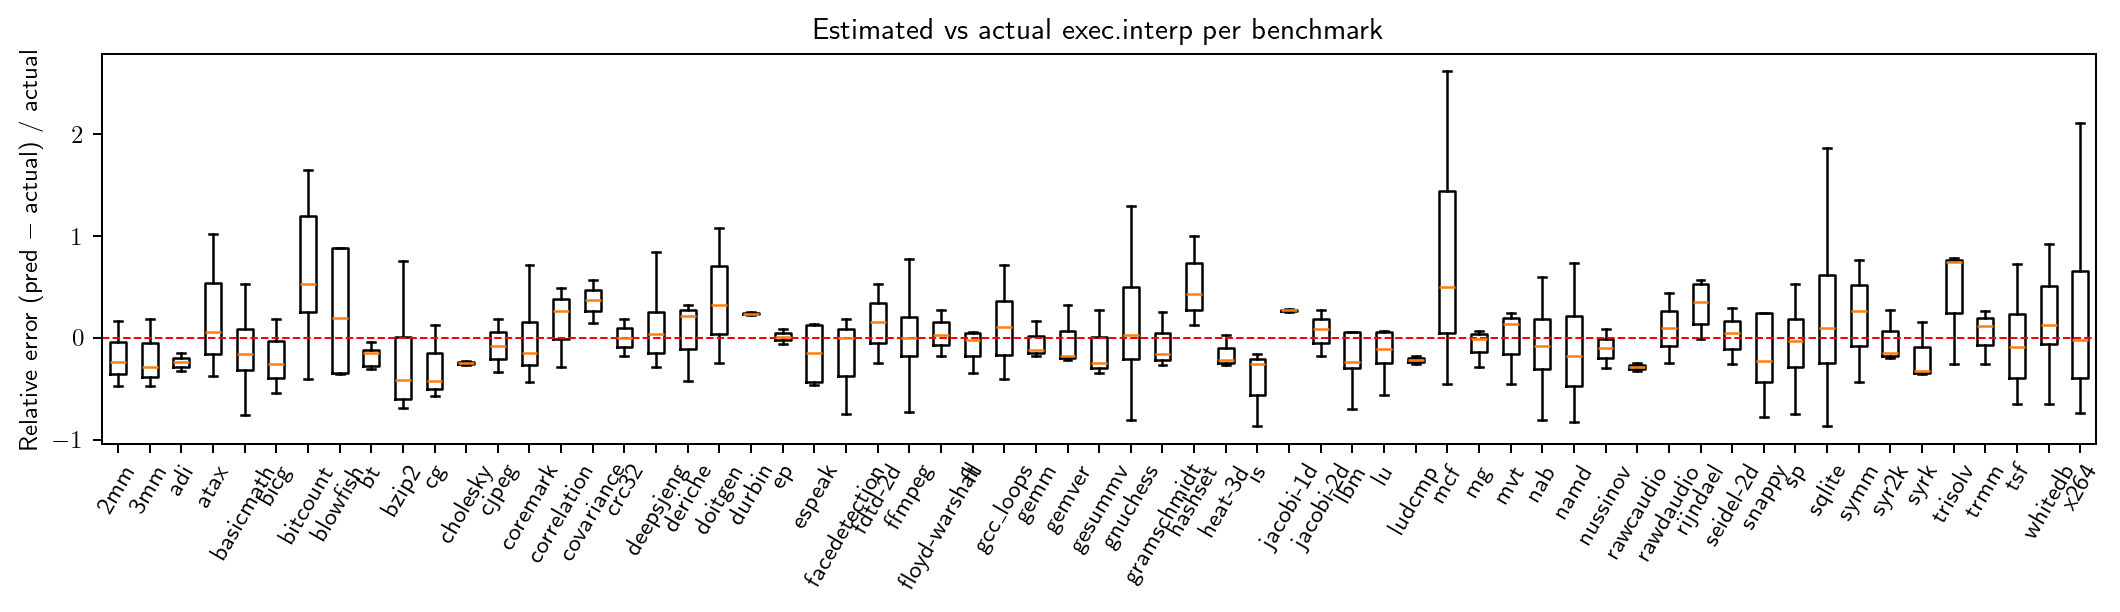

In [14]:
fig, ax = plt.subplots(figsize=(12, 3.5), dpi=180)

bench_names = sorted(errors_by_benchmark.keys())
data_list   = [errors_by_benchmark[b] for b in bench_names]

ax.boxplot(data_list, vert=True, labels=bench_names, showfliers=False)
ax.axhline(0, color='red', lw=0.8, linestyle='--')
ax.set_ylabel('Relative error (pred $-$ actual) / actual')
ax.set_title('Estimated vs actual exec.interp per benchmark')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

## Impact on planner decisions

The planner minimises end-to-end time subject to a dynamic code-size budget
(≤ 10 % of the all-JIT code size).  Here we check that plans generated from
the **estimated** profile match those from the **oracle** profile under this
constrained objective.


In [15]:
from solver import Solver, EndToEndTime, DynamicCodeSize, Constraint


def plan_agreement(oracle_profile: pd.DataFrame, estimated_profile: pd.DataFrame) -> float:
    """Fraction of functions assigned the same mode by oracle vs estimated profile."""
    for profile, attr in [(oracle_profile, 's_oracle'), (estimated_profile, 's_est')]:
        s = Solver(profile)
        s.solve(
            goal=EndToEndTime(),
            constraints=make_constraints(profile),
            log=False,
            timeout=10,
        )
        if attr == 's_oracle':
            s_oracle = s
        else:
            s_est = s

    plan_o = s_oracle.plan.set_index('id')['mode']
    plan_e = s_est.plan.set_index('id')['mode']

    common = plan_o.index.intersection(plan_e.index)
    return float((plan_o[common] == plan_e[common]).mean())


agreements = []
for f in sorted(PROFILE_ROOT.rglob('profile.csv')):
    oracle = pd.read_csv(f).fillna(0)
    if (oracle['exec.jit'] > 0).sum() < 5:
        continue
    estimated = merge_estimated_profile(oracle)
    try:
        agr = plan_agreement(oracle, estimated)
        bench = f.parts[-3]
        wl    = f.parts[-2]
        agreements.append({'benchmark': bench, 'workload': wl, 'agreement': agr})
        print(f"{bench}/{wl:30s}  agreement = {agr:.3f}")
    except Exception as e:
        print(f"  [skip] {f}: {e}")

agr_df = pd.DataFrame(agreements)
if len(agr_df):
    print(f"\nOverall mean plan agreement: {agr_df['agreement'].mean():.3f}")
    print(f"Min: {agr_df['agreement'].min():.3f}   Max: {agr_df['agreement'].max():.3f}")


  [skip] /users/khordadi/truejit/profiles/coremark/default/profile.csv: name 'make_constraints' is not defined
  [skip] /users/khordadi/truejit/profiles/ffmpeg/jpegs-to-mp4/profile.csv: name 'make_constraints' is not defined
  [skip] /users/khordadi/truejit/profiles/ffmpeg/mov-to-mp4/profile.csv: name 'make_constraints' is not defined
  [skip] /users/khordadi/truejit/profiles/ffmpeg/mp4-flip-vertical/profile.csv: name 'make_constraints' is not defined
  [skip] /users/khordadi/truejit/profiles/ffmpeg/mp4-gaussian-blur/profile.csv: name 'make_constraints' is not defined
  [skip] /users/khordadi/truejit/profiles/ffmpeg/mp4-mono-audio/profile.csv: name 'make_constraints' is not defined
  [skip] /users/khordadi/truejit/profiles/ffmpeg/mp4-remove-audio/profile.csv: name 'make_constraints' is not defined
  [skip] /users/khordadi/truejit/profiles/ffmpeg/mp4-resize-720p/profile.csv: name 'make_constraints' is not defined
  [skip] /users/khordadi/truejit/profiles/ffmpeg/mp4-slowdown-2x/profile.c

## E2E plan quality evaluation

**Objective**: minimise end-to-end time subject to a code-size constraint:
total dynamic code size of the plan ≤ 10 % of what pure JIT would produce.

For every benchmark/workload we:
1. Solve on the **oracle** (actual) profile → `oracle_plan`
2. Solve on the **estimated** profile (estimated interp) → `estimated_plan`
3. Evaluate both plans on the actual profile using the `EndToEndTime` objective

The ratio `estimated_plan_e2e / oracle_plan_e2e` quantifies how much quality
is lost by relying on the estimator instead of a real interp measurement.


In [16]:
from solver import Solver, EndToEndTime, DynamicCodeSize, Constraint

CODE_SIZE_FRACTION = 0.10  # plan code size must be < 10% of all-JIT code size


def make_constraints(profile: pd.DataFrame) -> list:
    """Code-size budget: at most CODE_SIZE_FRACTION of the all-JIT dynamic code size."""
    budget = CODE_SIZE_FRACTION * float(profile['size.dynamic.jit'].fillna(0).sum())
    return [Constraint(DynamicCodeSize(), upper_bound=budget)]


def solve_plan(profile: pd.DataFrame, timeout: int = 10) -> pd.DataFrame:
    solver = Solver(profile)
    solver.solve(
        goal=EndToEndTime(),
        constraints=make_constraints(profile),
        log=False,
        timeout=timeout,
    )
    return solver.plan


def eval_plan_on_profile(actual_profile: pd.DataFrame, plan: pd.DataFrame) -> float:
    """
    Compute the EndToEndTime objective value for *plan* evaluated against
    the costs in *actual_profile* (ground-truth profile).
    """
    df = actual_profile.set_index('id')
    pd_idx = plan.set_index('id')
    common = df.index.intersection(pd_idx.index)
    df  = df.loc[common]
    m   = pd_idx.loc[common, 'mode'].values

    exec_jit    = df['exec.jit'].values.astype(float)
    comp_jit    = df['compilation.jit'].values.astype(float)
    exec_interp = df['exec.interp'].values.astype(float)
    exec_spec   = df['exec.spec'].values.astype(float)
    comp_spec   = df['compilation.spec'].values.astype(float)

    cost = np.where(m == 'interpret', exec_interp,
           np.where(m == 'jit',       exec_jit + comp_jit,
           np.where(m == 'static',    exec_jit,
           np.where(m == 'async',     exec_jit + 0.5 * comp_jit,
           np.where(m == 'specialize', exec_spec + comp_spec,
           0.0)))))
    return float(cost.sum())


def mode_distribution(plan: pd.DataFrame) -> dict:
    return plan['mode'].value_counts().to_dict()


print(f'Helpers defined.  Code-size constraint: <= {CODE_SIZE_FRACTION:.0%} of all-JIT.')


Helpers defined.  Code-size constraint: <= 10% of all-JIT.


In [17]:
# Pre-train one LOO model per benchmark so the evaluation never tests
# on data the model was trained on.
loo_models = {}  # benchmark -> GBR trained on all OTHER benchmarks

for held_out in sorted(train_raw['benchmark'].unique()):
    mask = train_raw['benchmark'] != held_out
    if mask.sum() < 20:
        print(f'  [fallback] {held_out}: only {mask.sum()} samples, using full model')
        loo_models[held_out] = final_model
        continue
    m = make_gbr()
    m.fit(X_all[mask], y_all[mask])
    loo_models[held_out] = m
    print(f'  LOO model for {held_out:25s}  ({mask.sum()} training samples)')

print(f'\nLOO models ready: {len(loo_models)}')


  LOO model for 2mm                        (3242 training samples)
  LOO model for 3mm                        (3242 training samples)
  LOO model for adi                        (3243 training samples)
  LOO model for atax                       (3242 training samples)
  LOO model for basicmath                  (3232 training samples)
  LOO model for bicg                       (3242 training samples)
  LOO model for bitcount                   (3239 training samples)
  LOO model for blowfish                   (3240 training samples)
  LOO model for bt                         (3238 training samples)
  LOO model for bzip2                      (3239 training samples)
  LOO model for cg                         (3242 training samples)
  LOO model for cholesky                   (3243 training samples)
  LOO model for cjpeg                      (3243 training samples)
  LOO model for coremark                   (3237 training samples)
  LOO model for correlation                (3242 training samp

In [18]:
MIN_HOT_FNS = 3   # skip profiles with too few called functions

eval_results = []

for f in sorted(PROFILE_ROOT.rglob('profile.csv')):
    actual = pd.read_csv(f).fillna(0)
    if (actual['exec.jit'] > 0).sum() < MIN_HOT_FNS:
        continue

    bench = f.parts[-3]
    model = loo_models.get(bench, final_model)
    estimated = merge_estimated_profile(actual, model=model)

    try:
        oracle_plan    = solve_plan(actual)
        estimated_plan = solve_plan(estimated)
    except Exception as e:
        print(f'  [skip] {f.parts[-3]}/{f.parts[-2]}: {e}')
        continue

    oracle_e2e    = eval_plan_on_profile(actual, oracle_plan)
    estimated_e2e = eval_plan_on_profile(actual, estimated_plan)

    if oracle_e2e == 0:
        continue

    ratio = estimated_e2e / oracle_e2e

    # plan mode distributions
    oracle_modes = mode_distribution(oracle_plan)
    estimated_modes = mode_distribution(estimated_plan)

    # per-mode disagreements
    joined = oracle_plan.set_index('id')['mode'].rename('oracle').to_frame()
    joined['estimated'] = estimated_plan.set_index('id')['mode']
    joined = joined.dropna()
    agreement = (joined['oracle'] == joined['estimated']).mean()

    eval_results.append({
        'benchmark': f.parts[-3],
        'workload':  f.parts[-2],
        'oracle_e2e':    oracle_e2e,
        'estimated_e2e': estimated_e2e,
        'ratio':         ratio,
        'agreement':     agreement,
        'oracle_modes':    oracle_modes,
        'estimated_modes': estimated_modes,
    })
    print(f"{f.parts[-3]:15s}/{f.parts[-2]:30s}  ratio={ratio:.3f}  agree={agreement:.3f}")

res_df = pd.DataFrame(eval_results)
print(f"\n--- Summary ---")
print(f"Profiles evaluated : {len(res_df)}")
print(f"Mean   ratio       : {res_df['ratio'].mean():.4f}")
print(f"Median ratio       : {res_df['ratio'].median():.4f}")
print(f"Max    ratio       : {res_df['ratio'].max():.4f}")
print(f"Mean   agreement   : {res_df['agreement'].mean():.4f}")

[goal] EndToEndTime
[constraint] DynamicCodeSize <= 10635.2
Solving...
[status] Optimal
[elapsed time] 0.05 seconds
[goal] EndToEndTime


[constraint] DynamicCodeSize <= 10635.2
Solving...
[status] Optimal
[elapsed time] 0.05 seconds
coremark       /default                         ratio=1.004  agree=0.953
[goal] EndToEndTime
[constraint] DynamicCodeSize <= 303317.60000000003
Solving...
[status] Optimal
[elapsed time] 0.41 seconds
[goal] EndToEndTime
[constraint] DynamicCodeSize <= 303317.60000000003
Solving...
[status] Optimal
[elapsed time] 0.37 seconds
ffmpeg         /jpegs-to-mp4                    ratio=16.803  agree=0.715
[goal] EndToEndTime
[constraint] DynamicCodeSize <= 506740.80000000005
Solving...
[status] Optimal
[elapsed time] 0.40 seconds
[goal] EndToEndTime
[constraint] DynamicCodeSize <= 506740.80000000005
Solving...
[status] Optimal
[elapsed time] 0.36 seconds
ffmpeg         /mov-to-mp4                      ratio=1.300  agree=0.983
[goal] EndToEndTime
[constraint] DynamicCodeSize <= 507828.0
Solving...
[status] Optimal
[elapsed time] 0.48 seconds
[goal] EndToEndTime
[constraint] DynamicCodeSize <= 507828.

/tmp/ipykernel_219179/3214619012.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


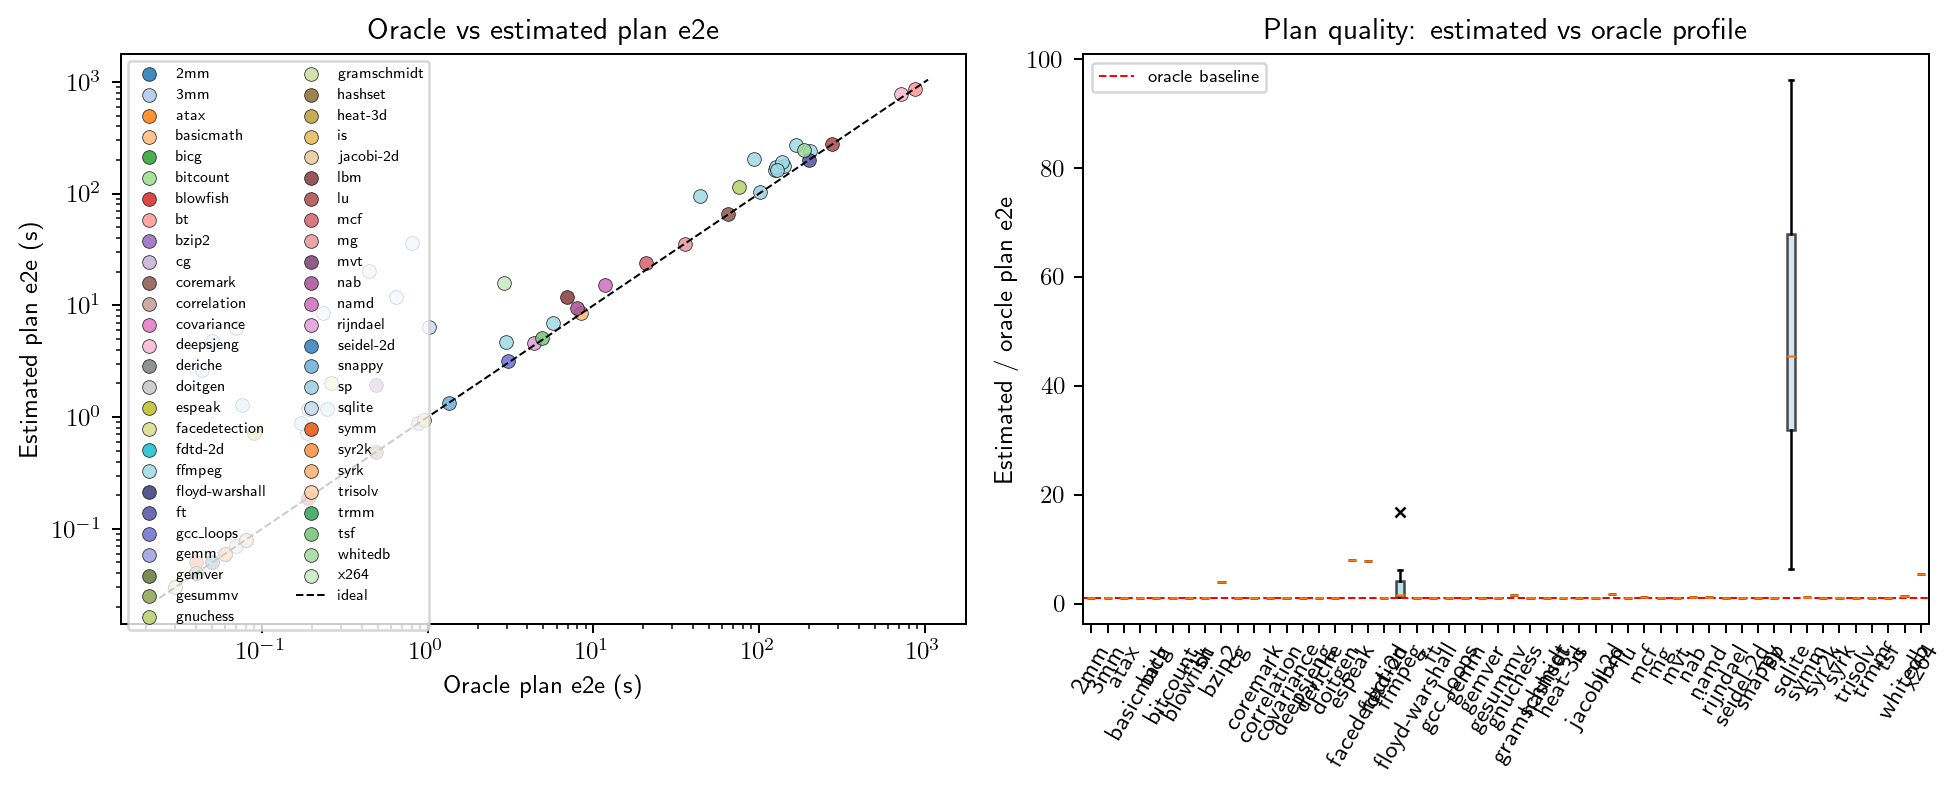

In [19]:
# -----------------------------------------------------------------------
# Figure 1 – overview
# Left:  scatter oracle_e2e vs estimated_e2e (log–log)
# Right: box plot of e2e ratio per benchmark
# -----------------------------------------------------------------------

_all_colors = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
BENCH_COLORS = {
    b: _all_colors[i % len(_all_colors)]
    for i, b in enumerate(sorted(res_df['benchmark'].unique()))
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=180)

# -- scatter --
ax = axes[0]
for bench, grp in res_df.groupby('benchmark'):
    ax.scatter(
        grp['oracle_e2e'] / 1e9,
        grp['estimated_e2e'] / 1e9,
        label=bench,
        color=BENCH_COLORS[bench],
        s=30, alpha=0.85, edgecolors='black', linewidths=0.3,
    )

lim_lo = min(res_df['oracle_e2e'].min(), res_df['estimated_e2e'].min()) / 1e9 * 0.8
lim_hi = max(res_df['oracle_e2e'].max(), res_df['estimated_e2e'].max()) / 1e9 * 1.2
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=0.8, label='ideal')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Oracle plan e2e (s)')
ax.set_ylabel('Estimated plan e2e (s)')
ax.set_title('Oracle vs estimated plan e2e')
ax.legend(fontsize=6, ncol=2, loc='upper left')

# -- ratio box plot per benchmark --
ax = axes[1]
bench_order = sorted(res_df['benchmark'].unique())
data_per_bench = [res_df[res_df['benchmark'] == b]['ratio'].values for b in bench_order]

bp = ax.boxplot(
    data_per_bench,
    vert=True,
    labels=bench_order,
    showfliers=True,
    flierprops=dict(marker='x', markersize=4, linestyle='none'),
    patch_artist=True,
)
for patch, bench in zip(bp['boxes'], bench_order):
    patch.set_facecolor(BENCH_COLORS[bench])
    patch.set_alpha(0.7)

ax.axhline(1.0, color='red', lw=0.8, linestyle='--', label='oracle baseline')
ax.set_ylabel('Estimated / oracle plan e2e')
ax.set_title('Plan quality: estimated vs oracle profile')
ax.tick_params(axis='x', rotation=60)
ax.legend(fontsize=7)

plt.tight_layout()
Path('out').mkdir(exist_ok=True)
plt.savefig('out/e2e-plan-quality-summary.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()

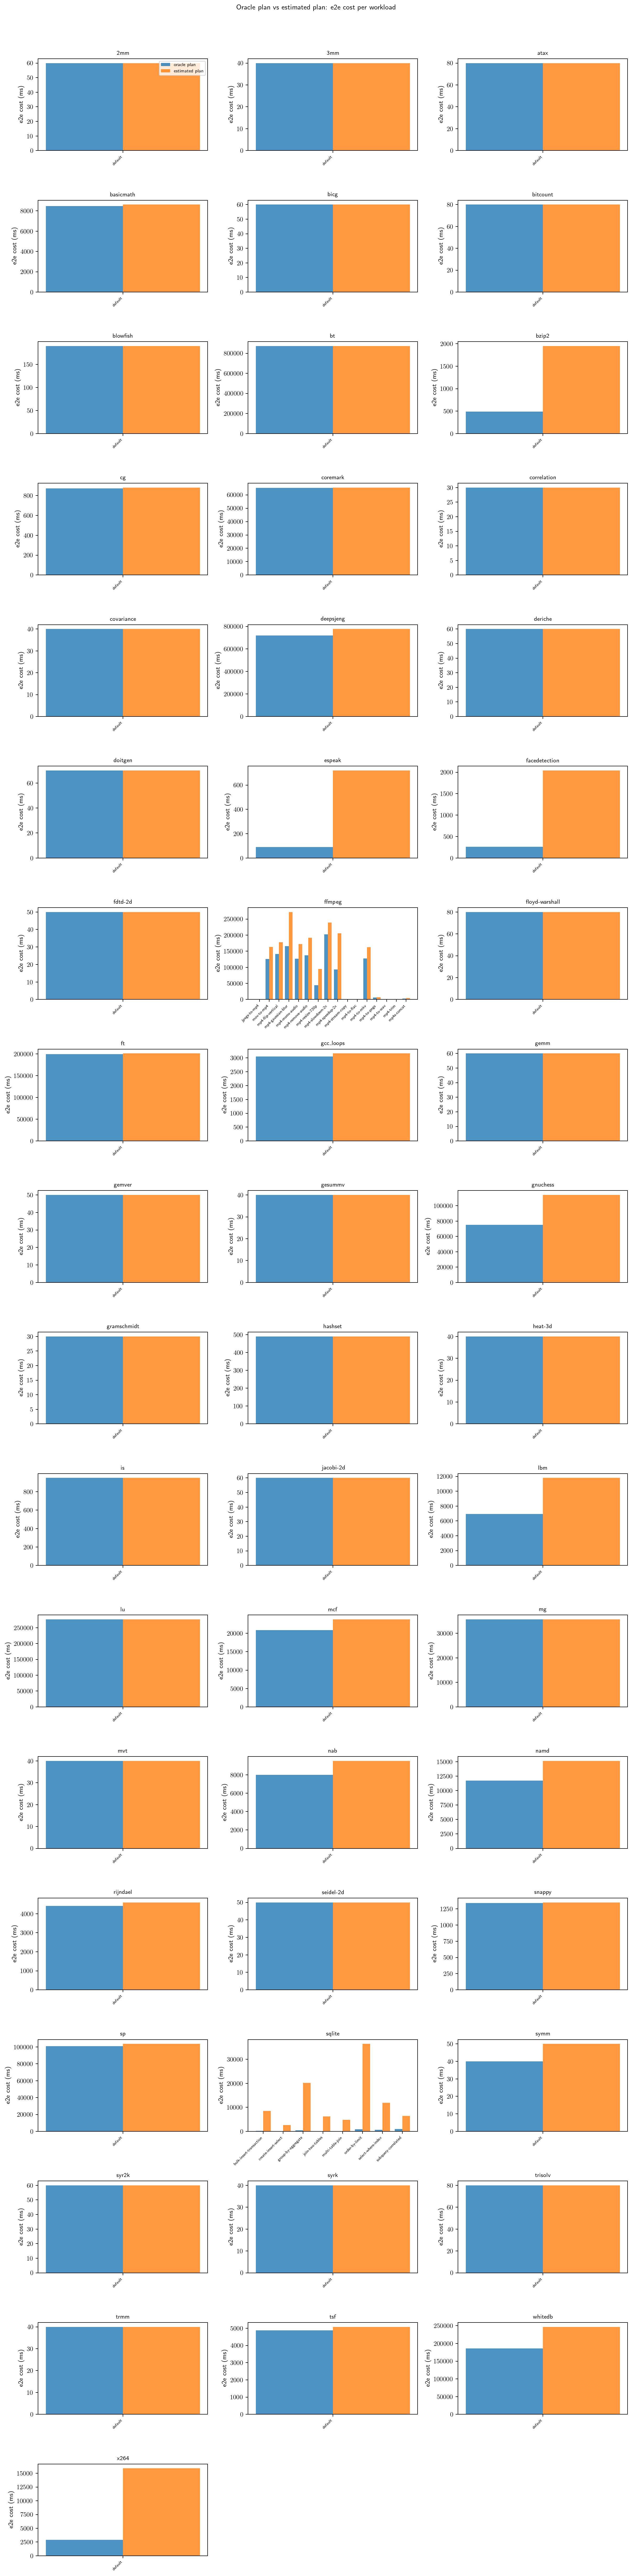

In [20]:
# -----------------------------------------------------------------------
# Figure 2 – per-benchmark detail
# Each panel is one benchmark; bars show oracle vs estimated e2e per workload.
# -----------------------------------------------------------------------

bench_groups = res_df.groupby('benchmark')
n_benches = len(bench_groups)

# arrange as a grid: 3 columns
ncols = 3
nrows = (n_benches + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3), dpi=180)
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for ax_idx, (bench, grp) in enumerate(sorted(bench_groups)):
    ax = axes_flat[ax_idx]
    grp = grp.sort_values('workload')

    wl_labels = grp['workload'].tolist()
    x = np.arange(len(wl_labels))
    w = 0.38

    oracle_ns    = grp['oracle_e2e'].values    / 1e6   # ms
    estimated_ns = grp['estimated_e2e'].values / 1e6   # ms

    ax.bar(x - w/2, oracle_ns,    width=w, label='oracle plan',    color='tab:blue',   alpha=0.8)
    ax.bar(x + w/2, estimated_ns, width=w, label='estimated plan', color='tab:orange', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(wl_labels, rotation=45, ha='right', fontsize=6)
    ax.set_ylabel('e2e cost (ms)')
    ax.set_title(bench, fontsize=9)
    if ax_idx == 0:
        ax.legend(fontsize=7)

# hide unused subplots
for ax in axes_flat[n_benches:]:
    ax.set_visible(False)

plt.suptitle('Oracle plan vs estimated plan: e2e cost per workload', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('out/e2e-plan-quality-per-benchmark.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\#'
<>:44: SyntaxWarning: invalid escape sequence '\#'
/tmp/ipykernel_219179/1298537698.py:44: SyntaxWarning: invalid escape sequence '\#'
  plt.colorbar(im, ax=ax, label='\# functions')


[goal] EndToEndTime
[constraint] DynamicCodeSize <= 10635.2
Solving...
[status] Optimal
[elapsed time] 0.05 seconds
[goal] EndToEndTime
[constraint] DynamicCodeSize <= 10635.2
Solving...
[status] Optimal
[elapsed time] 0.05 seconds
[goal] EndToEndTime
[constraint] DynamicCodeSize <= 303317.60000000003
Solving...
[status] Optimal
[elapsed time] 0.41 seconds
[goal] EndToEndTime
[constraint] DynamicCodeSize <= 303317.60000000003
Solving...
[status] Optimal
[elapsed time] 0.37 seconds
[goal] EndToEndTime
[constraint] DynamicCodeSize <= 506740.80000000005
Solving...
[status] Optimal
[elapsed time] 0.28 seconds
[goal] EndToEndTime
[constraint] DynamicCodeSize <= 506740.80000000005
Solving...
[status] Optimal
[elapsed time] 0.52 seconds
[goal] EndToEndTime
[constraint] DynamicCodeSize <= 507828.0
Solving...
[status] Optimal
[elapsed time] 0.55 seconds
[goal] EndToEndTime
[constraint] DynamicCodeSize <= 507828.0
Solving...
[status] Optimal
[elapsed time] 0.60 seconds
[goal] EndToEndTime
[const

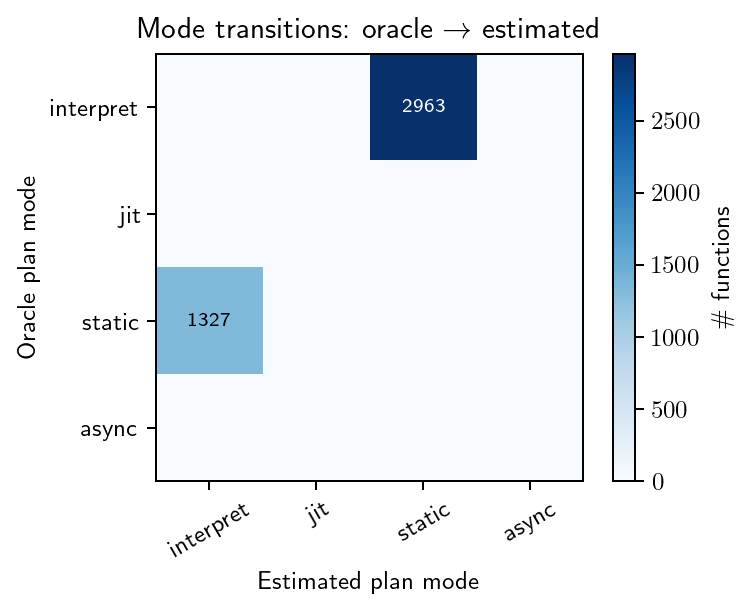

In [21]:
# -----------------------------------------------------------------------
# Figure 3 – what changes between oracle and estimated plans?
# Heatmap of mode transitions: oracle plan mode → estimated plan mode.
# -----------------------------------------------------------------------

from collections import defaultdict

# Build the set of (benchmark, workload) pairs that were successfully evaluated
evaluated_keys = {(r['benchmark'], r['workload']) for r in eval_results}

mode_diffs = defaultdict(int)  # (oracle_mode, estimated_mode) -> count

for f in sorted(PROFILE_ROOT.rglob('profile.csv')):
    key = (f.parts[-3], f.parts[-2])
    if key not in evaluated_keys:
        continue

    actual = pd.read_csv(f).fillna(0)
    model = loo_models.get(f.parts[-3], final_model)
    estimated = merge_estimated_profile(actual, model=model)
    oracle_plan    = solve_plan(actual)
    estimated_plan = solve_plan(estimated)

    joined = oracle_plan.set_index('id')['mode'].rename('oracle').to_frame()
    joined['estimated'] = estimated_plan.set_index('id')['mode']
    joined = joined.dropna()

    for _, prow in joined[joined['oracle'] != joined['estimated']].iterrows():
        mode_diffs[(prow['oracle'], prow['estimated'])] += 1

# build transition matrix
from solver import all_modes
active_modes = ['interpret', 'jit', 'static', 'async']
matrix = pd.DataFrame(0, index=active_modes, columns=active_modes)
for (oracle_mode, est_mode), cnt in mode_diffs.items():
    if oracle_mode in active_modes and est_mode in active_modes:
        matrix.loc[oracle_mode, est_mode] += cnt

total_diffs = sum(mode_diffs.values())
print(f'Total function-mode changes across all evaluated profiles: {total_diffs}')

fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=180)
im = ax.imshow(matrix.values, cmap='Blues')
plt.colorbar(im, ax=ax, label='\# functions')
ax.set_xticks(range(len(active_modes)))
ax.set_yticks(range(len(active_modes)))
ax.set_xticklabels(active_modes, rotation=30)
ax.set_yticklabels(active_modes)
ax.set_xlabel('Estimated plan mode')
ax.set_ylabel('Oracle plan mode')
ax.set_title(r'Mode transitions: oracle $\to$ estimated')
for i in range(len(active_modes)):
    for j in range(len(active_modes)):
        v = int(matrix.iloc[i, j])
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=8,
                    color='white' if v > matrix.values.max() * 0.5 else 'black')

plt.tight_layout()
plt.savefig('out/e2e-mode-transitions.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()


## Usage

```python
# Option A: convenience function from a CSV file
merged = estimate_from_csv(
    '/users/khordadi/truejit/profiles/ffmpeg/mov-to-mp4/profile.csv',
    output_csv='/tmp/estimated_profile.csv',
)

# Option B: inline with a DataFrame
import pandas as pd
jit_df = pd.read_csv('my_jit_only_profile.csv')
merged = merge_estimated_profile(jit_df)   # uses global final_model

# Feed directly to the planner
from solver import Solver, EndToEndTime
solver = Solver(merged)
solver.solve(goal=EndToEndTime())
```

In [22]:
# Smoke-test: load one profile and produce a merged estimated profile
example_path = next(PROFILE_ROOT.rglob('profile.csv'))
print("Using:", example_path)

merged_example = estimate_from_csv(example_path)
print(f"Merged profile: {len(merged_example)} functions")
print(merged_example[['id', 'name', 'exec.jit', 'exec.interp']].head(10).to_string(index=False))

Using: /users/khordadi/truejit/profiles/coremark/default/profile.csv
Merged profile: 64 functions
 id                  name  exec.jit  exec.interp
  9                _start         0            0
  8     __wasm_call_ctors         0            0
 42           __main_void         0            0
 44 __wasi_args_sizes_get         0            0
 34                malloc         0            0
 35              dlmalloc         0            0
 39                calloc         0            0
 86                memset         0            0
 43       __wasi_args_get         0            0
 14                  main         0            0


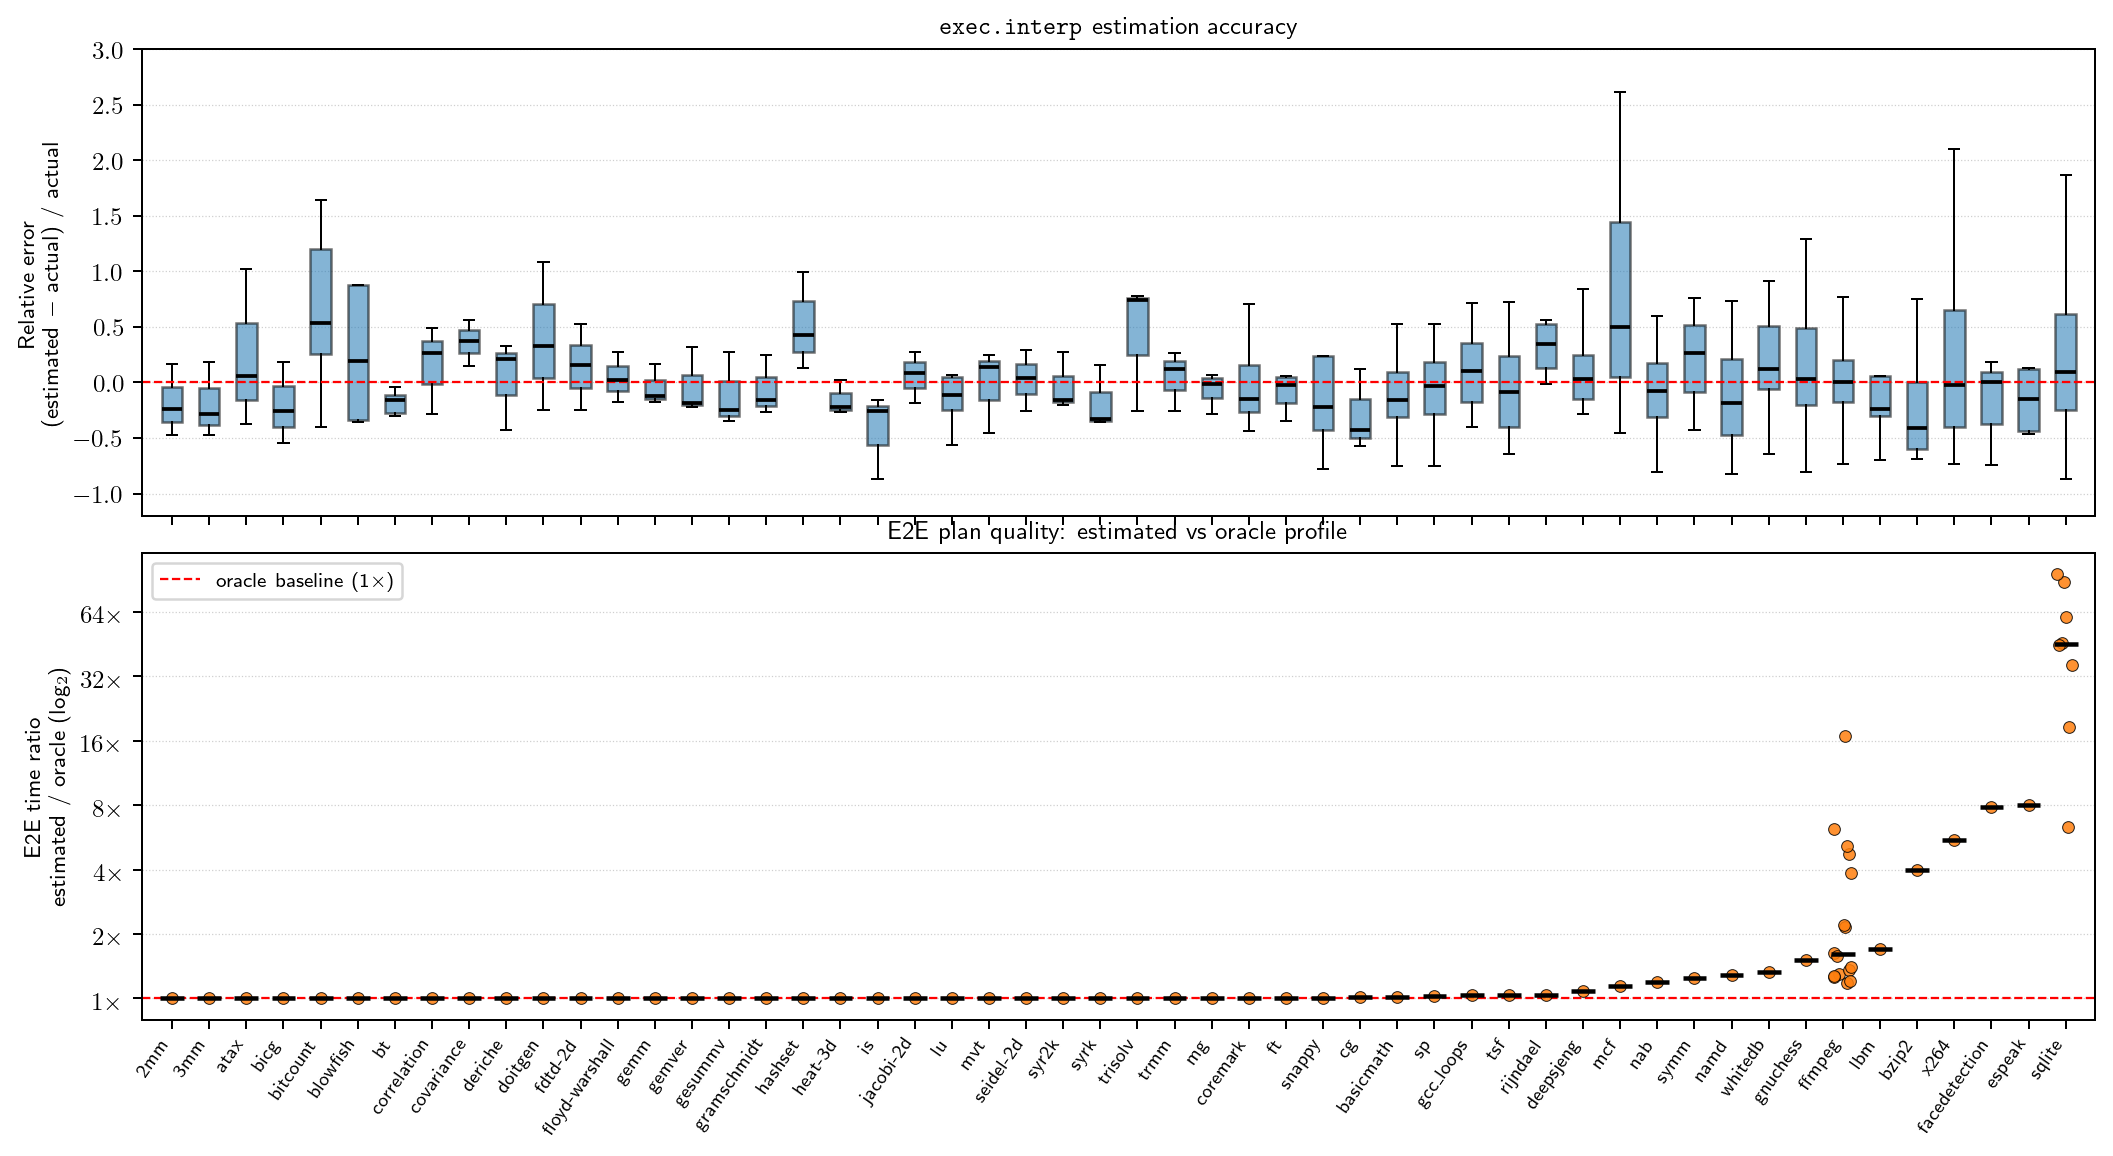

In [27]:

# -----------------------------------------------------------------------
# Figure: 2 rows × 1 col
# Row 1 – exec.interp estimation accuracy: box plot of per-function
#          relative error  (estimated − actual) / actual  per benchmark
# Row 2 – E2E plan quality: strip plot of estimated/oracle e2e ratio
#          per workload (most benchmarks have 1 workload; ffmpeg=17,
#          sqlite=8).  Box plots degenerate to lines for n=1, so we
#          draw individual dots + a median tick instead.
# Both rows share x-axis ordered by median e2e ratio (best → worst).
# -----------------------------------------------------------------------

rng = np.random.default_rng(0)

r1_benches = set(errors_by_benchmark.keys())
r2_benches = set(res_df['benchmark'].unique())
common = sorted(r1_benches & r2_benches)

median_ratio = {b: np.median(res_df[res_df['benchmark'] == b]['ratio'].values) for b in common}
bench_order  = sorted(common, key=lambda b: median_ratio[b])

r1_data = [errors_by_benchmark[b]                           for b in bench_order]
r2_data = [res_df[res_df['benchmark'] == b]['ratio'].values  for b in bench_order]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), dpi=180, sharex=True)
fig.subplots_adjust(hspace=0.08)

x = np.arange(len(bench_order))

# ── Row 1: exec.interp relative error (linear, box plot) ─────────────
ax1 = axes[0]
ax1.boxplot(
    r1_data,
    positions=x, widths=0.55, showfliers=False, patch_artist=True,
    medianprops=dict(color='black', lw=1.5),
    boxprops=dict(facecolor='tab:blue', alpha=0.55),
    whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8),
)
ax1.axhline(0, color='red', lw=0.9, linestyle='--')
ax1.set_ylabel('Relative error\n(estimated $-$ actual) / actual', fontsize=9)
ax1.set_title(r'\texttt{exec.interp} estimation accuracy', fontsize=10)
ax1.set_ylim(-1.2, 3.0)
ax1.yaxis.grid(True, linestyle=':', lw=0.5, alpha=0.6)

# ── Row 2: E2E ratio strip plot (log scale) ───────────────────────────
ax2 = axes[1]

for i, (b, vals) in enumerate(zip(bench_order, r2_data)):
    n = len(vals)
    # small horizontal jitter for benchmarks with multiple workloads
    jitter = rng.uniform(-0.25, 0.25, size=n) if n > 1 else np.zeros(1)
    ax2.scatter(
        i + jitter, vals,
        s=22, color='tab:orange', edgecolors='black', linewidths=0.4,
        alpha=0.85, zorder=3,
    )
    # median tick
    med = float(np.median(vals))
    ax2.plot([i - 0.32, i + 0.32], [med, med],
             color='black', lw=1.8, solid_capstyle='butt', zorder=4)

ax2.axhline(1.0, color='red', lw=0.9, linestyle='--', zorder=2, label='oracle baseline (1$\\times$)')
ax2.set_yscale('log', base=2)

import matplotlib.ticker as ticker
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'${v:g}\\times$'))
ax2.yaxis.set_minor_formatter(ticker.NullFormatter())

ax2.set_ylabel('E2E time ratio\nestimated / oracle  (log$_2$)', fontsize=9)
ax2.set_title('E2E plan quality: estimated vs oracle profile', fontsize=10)
ax2.yaxis.grid(True, which='major', linestyle=':', lw=0.5, alpha=0.6)
ax2.legend(fontsize=8, loc='upper left')

ax2.set_xticks(x)
ax2.set_xticklabels(bench_order, rotation=55, ha='right', fontsize=7.5)
ax2.set_xlim(-0.8, len(bench_order) - 0.2)

plt.savefig('out/estimator-accuracy-and-e2e.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()
